<a href="https://colab.research.google.com/github/Tarteel89/Income-Prediction/blob/main/Income_Prediction_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 — Part 2: Feature Engineering & Selection

Continuing from Part 1. Steps:
1. Feature Engineering: PCA (3 components) + KMeans cluster labels — concatenated with original features
2. Model on engineered features vs Part 1 baseline
3. Feature Selection: embedded method (`SelectFromModel`)
4. Final model on selected features
5. Permutation importance + comparison commentary


---
## Setup — Re-run Preprocessing from Part 1

In [27]:
import datetime as dt, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn import set_config
set_config(transform_output='pandas')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
pd.set_option('display.max_columns', 30)
RANDOM_STATE = 321



In [28]:
def classification_metrics(y_true, y_pred, label=''):
    return pd.DataFrame(classification_report(y_true, y_pred, output_dict=True)).T.round(4)

def evaluate_classification(model, X_tr, y_tr, X_te, y_te, title='Model'):
    for name, X, y in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        yp = model.predict(X)
        print(f'\n── {title} | {name} ── Accuracy: {accuracy_score(y,yp):.4f}')
        display(classification_metrics(y, yp))
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, norm, sub in zip(axes, [None,'true'], ['Raw','Normalised']):
            ConfusionMatrixDisplay(
                confusion_matrix(y, yp, normalize=norm),
                display_labels=model.classes_
            ).plot(ax=ax, colorbar=False, cmap='Blues')
            ax.set_title(f'{title} — {name} | {sub}')
        plt.tight_layout(); plt.show()




In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Full preprocessing pipeline (Part 1 reproduction)
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week12/adult.csv')
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
str_c = df.select_dtypes(include='object').columns
df[str_c] = df[str_c].apply(lambda c: c.str.strip())

target_col = 'income'
drop_cols  = ['fnlwgt', 'education']
df[target_col] = (df[target_col] == '>50K').astype(int)
df_d = df.drop(columns=drop_cols)
cat_cols = df_d.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df_d, columns=cat_cols, drop_first=True)

X = df_enc.drop(columns=[target_col])
y = df_enc[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f'Train (SMOTE): {X_train_sm.shape} | Test: {X_test_sc.shape}')


Train (SMOTE): (54422, 80) | Test: (9045, 80)


Baseline time: 11.93s

── Part 1 — RF Baseline | Train ── Accuracy: 0.9800


,precision,recall,f1-score,support
0,0.9823,0.9776,0.9799,27211.00
1,0.9777,0.9824,0.9800,27211.00
accuracy,0.9800,0.9800,0.9800,0.98
macro avg,0.9800,0.9800,0.9800,54422.00
weighted avg,0.9800,0.9800,0.9800,54422.00


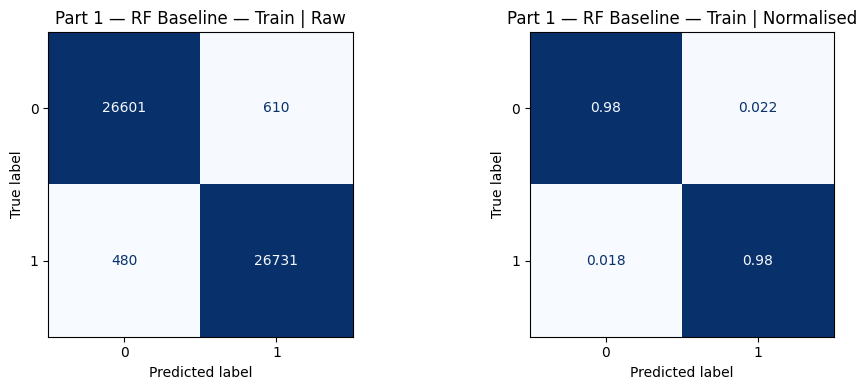


── Part 1 — RF Baseline | Test ── Accuracy: 0.8383


,precision,recall,f1-score,support
0,0.8978,0.8858,0.8917,6803.0000
1,0.6670,0.6940,0.6802,2242.0000
accuracy,0.8383,0.8383,0.8383,0.8383
macro avg,0.7824,0.7899,0.7860,9045.0000
weighted avg,0.8406,0.8383,0.8393,9045.0000


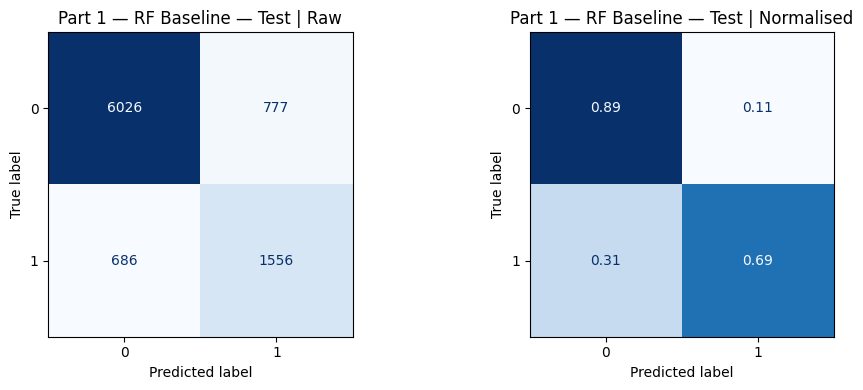

In [31]:
# Re-train Part 1 baseline for reference
t0 = dt.datetime.now()
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_sm, y_train_sm)
dur_base = (dt.datetime.now() - t0).total_seconds()
print(f'Baseline time: {dur_base:.2f}s')
evaluate_classification(rf_base, X_train_sm, y_train_sm, X_test_sc, y_test,
                        title='Part 1 — RF Baseline')


---
## Feature Engineering

Two methods applied and concatenated with original features:
- **PCA** — 3 principal components
- **KMeans** — cluster label per sample

> Fitted **only on training data**, then `.transform()` / `.predict()` applied to test data to prevent leakage.


In [32]:
# Step 1: PCA — 3 principal components
# Fit on train only, transform both
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
pca_tr = pd.DataFrame(pca3.fit_transform(X_train_sm), columns=['PC1','PC2','PC3'])
pca_te = pd.DataFrame(pca3.transform(X_test_sc),      columns=['PC1','PC2','PC3'])
print(f'Variance explained by 3 PCs: {pca3.explained_variance_ratio_.sum():.3f}')


Variance explained by 3 PCs: 0.103


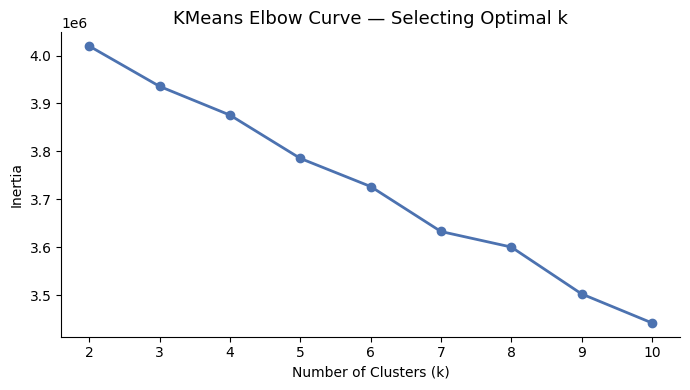

In [22]:
# Step 2: KMeans — elbow curve to select k
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_train_sm)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 11), inertias, marker='o', color='#4C72B0', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('KMeans Elbow Curve — Selecting Optimal k', fontsize=13)
sns.despine(); plt.tight_layout(); plt.show()


In [33]:
# Apply KMeans with chosen k (adjust BEST_K based on elbow curve)
BEST_K = 4
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_sm)   # fit on train only

# Use .predict() for test data — NOT fit_predict
cl_tr = pd.DataFrame(kmeans.predict(X_train_sm), columns=['cluster'])
cl_te = pd.DataFrame(kmeans.predict(X_test_sc),  columns=['cluster'])
print(f'Cluster counts (train): {cl_tr.value_counts().to_dict()}')


Cluster counts (train): {(1,): 32221, (3,): 20844, (0,): 1266, (2,): 91}
Cluster counts (train): {(1,): 32221, (3,): 20844, (0,): 1266, (2,): 91}


In [34]:
# Concatenate: original features + PCA components + cluster label
X_tr_df = pd.DataFrame(X_train_sm, columns=X.columns)
X_te_df = pd.DataFrame(X_test_sc,  columns=X.columns)

X_train_eng = pd.concat([X_tr_df.reset_index(drop=True),
                          pca_tr.reset_index(drop=True),
                          cl_tr.reset_index(drop=True)], axis=1)

X_test_eng  = pd.concat([X_te_df.reset_index(drop=True),
                          pca_te.reset_index(drop=True),
                          cl_te.reset_index(drop=True)], axis=1)

print(f'Engineered train: {X_train_eng.shape} | test: {X_test_eng.shape}')
print(f'New columns: PC1, PC2, PC3, cluster')


Engineered train: (54422, 84) | test: (9045, 84)
New columns: PC1, PC2, PC3, cluster
Engineered train: (54422, 84) | test: (9045, 84)
New columns: PC1, PC2, PC3, cluster


---
## Model on Engineered Features

Engineered model time: 15.00s

── RF + Engineered Features | Train ── Accuracy: 0.9800


,precision,recall,f1-score,support
0,0.9825,0.9774,0.9799,27211.00
1,0.9775,0.9825,0.9800,27211.00
accuracy,0.9800,0.9800,0.9800,0.98
macro avg,0.9800,0.9800,0.9800,54422.00
weighted avg,0.9800,0.9800,0.9800,54422.00


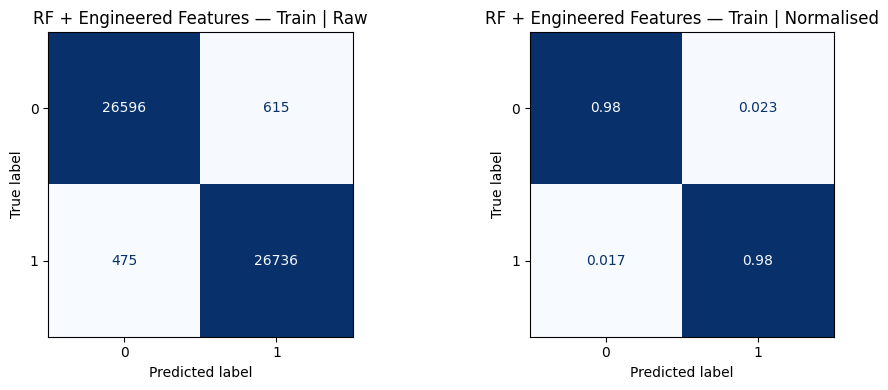


── RF + Engineered Features | Test ── Accuracy: 0.8369


,precision,recall,f1-score,support
0,0.8973,0.8845,0.8908,6803.0000
1,0.6640,0.6927,0.6780,2242.0000
accuracy,0.8369,0.8369,0.8369,0.8369
macro avg,0.7806,0.7886,0.7844,9045.0000
weighted avg,0.8394,0.8369,0.8381,9045.0000


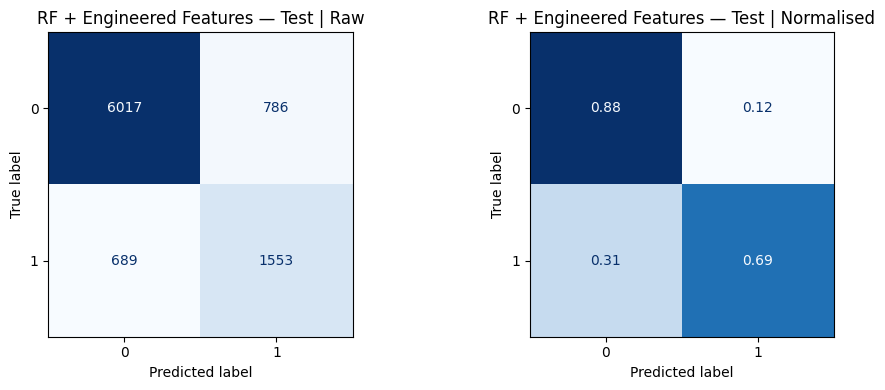

Engineered model time: 12.56s

── RF + Engineered Features | Train ── Accuracy: 0.9800


,precision,recall,f1-score,support
0,0.9825,0.9774,0.9799,27211.00
1,0.9775,0.9825,0.9800,27211.00
accuracy,0.9800,0.9800,0.9800,0.98
macro avg,0.9800,0.9800,0.9800,54422.00
weighted avg,0.9800,0.9800,0.9800,54422.00


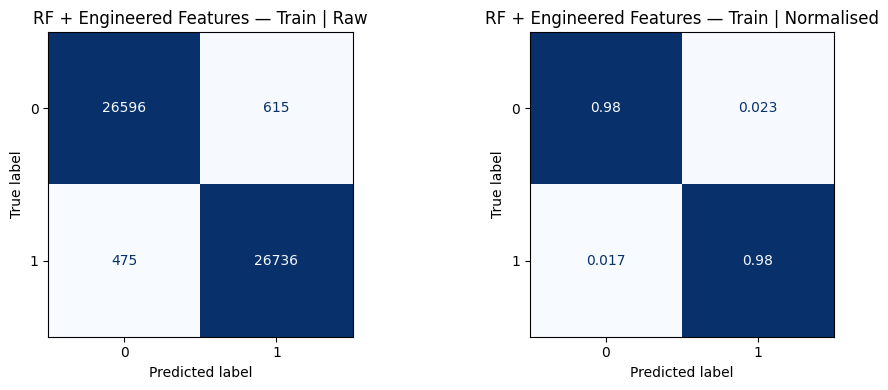


── RF + Engineered Features | Test ── Accuracy: 0.8369


,precision,recall,f1-score,support
0,0.8973,0.8845,0.8908,6803.0000
1,0.6640,0.6927,0.6780,2242.0000
accuracy,0.8369,0.8369,0.8369,0.8369
macro avg,0.7806,0.7886,0.7844,9045.0000
weighted avg,0.8394,0.8369,0.8381,9045.0000


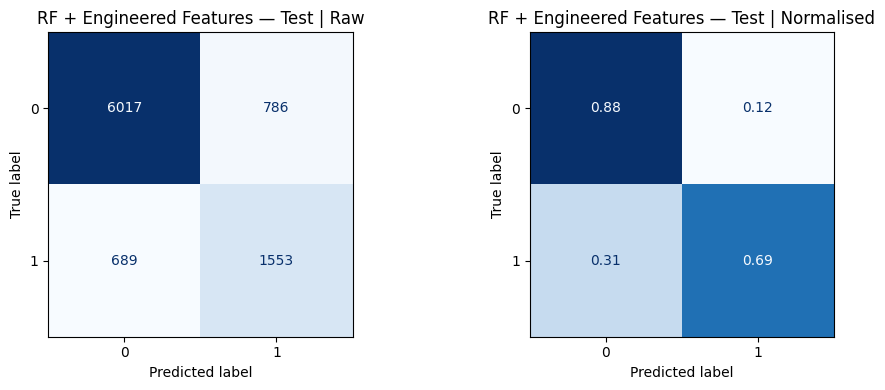

In [35]:
# Train RF on engineered feature set
t0 = dt.datetime.now()
rf_eng = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_eng.fit(X_train_eng, y_train_sm)
dur_eng = (dt.datetime.now() - t0).total_seconds()
print(f'Engineered model time: {dur_eng:.2f}s')
evaluate_classification(rf_eng, X_train_eng, y_train_sm, X_test_eng, y_test,
                        title='RF + Engineered Features')


---
## Feature Selection — Embedded Method (`SelectFromModel`)

Uses a Random Forest internally to score all features, then retains only those
above the **mean importance threshold** — an embedded approach that selects
features as part of model training itself.


In [36]:
# Fit SelectFromModel on engineered training data
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    threshold='mean'
)
selector.fit(X_train_eng, y_train_sm)

X_train_sel = selector.transform(X_train_eng)
X_test_sel  = selector.transform(X_test_eng)

sel_names = X_train_eng.columns[selector.get_support()].tolist()
print(f'Original: {X_train_eng.shape[1]} features  →  Selected: {len(sel_names)} features')
print('\nSelected features:')
for f in sel_names: print(f'  {f}')


Original: 84 features  →  Selected: 13 features

Selected features:
  age
  educational-num
  capital-gain
  capital-loss
  hours-per-week
  marital-status_Married-civ-spouse
  marital-status_Never-married
  occupation_Exec-managerial
  occupation_Prof-specialty
  relationship_Not-in-family
  relationship_Own-child
  gender_Male
  cluster
Original: 84 features  →  Selected: 13 features

Selected features:
  age
  educational-num
  capital-gain
  capital-loss
  hours-per-week
  marital-status_Married-civ-spouse
  marital-status_Never-married
  occupation_Exec-managerial
  occupation_Prof-specialty
  relationship_Not-in-family
  relationship_Own-child
  gender_Male
  cluster


Final model time: 13.77s

── RF Final — Selected Features | Train ── Accuracy: 0.9505


,precision,recall,f1-score,support
0,0.9428,0.9592,0.9509,27211.0000
1,0.9585,0.9418,0.9500,27211.0000
accuracy,0.9505,0.9505,0.9505,0.9505
macro avg,0.9506,0.9505,0.9505,54422.0000
weighted avg,0.9506,0.9505,0.9505,54422.0000


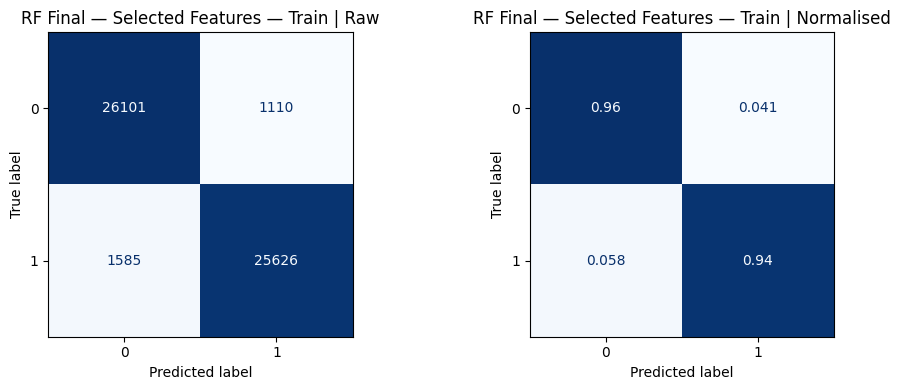


── RF Final — Selected Features | Test ── Accuracy: 0.8299


,precision,recall,f1-score,support
0,0.8893,0.8837,0.8865,6803.0000
1,0.6538,0.6664,0.6600,2242.0000
accuracy,0.8299,0.8299,0.8299,0.8299
macro avg,0.7716,0.7750,0.7733,9045.0000
weighted avg,0.8310,0.8299,0.8304,9045.0000


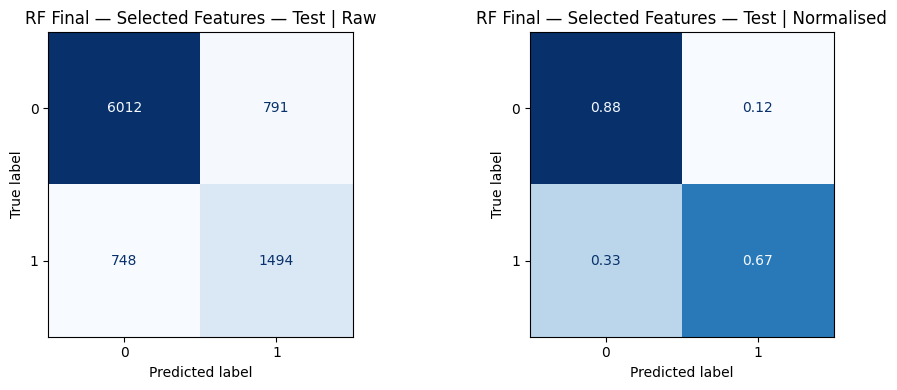

In [37]:
# Train final model on selected features only
t0 = dt.datetime.now()
rf_final = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train_sel, y_train_sm)
dur_final = (dt.datetime.now() - t0).total_seconds()
print(f'Final model time: {dur_final:.2f}s')
evaluate_classification(rf_final, X_train_sel, y_train_sm, X_test_sel, y_test,
                        title='RF Final — Selected Features')


,Model,# Features,Test Accuracy,Train Time (s)
0,Part 1 Baseline,80,0.838253,11.926625
1,Engineered Features,84,0.836926,12.558571
2,Final Selected,13,0.829851,13.774109


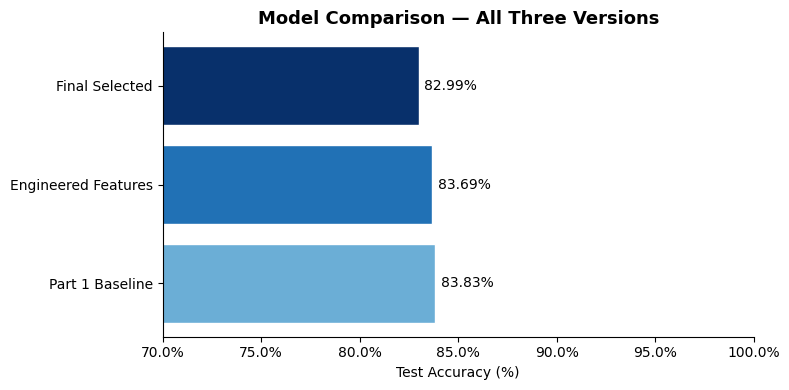

In [38]:
# Three-way comparison: Baseline vs Engineered vs Final
acc_base  = accuracy_score(y_test, rf_base.predict(X_test_sc))
acc_eng   = accuracy_score(y_test, rf_eng.predict(X_test_eng))
acc_final = accuracy_score(y_test, rf_final.predict(X_test_sel))

summary = pd.DataFrame({
    'Model':           ['Part 1 Baseline', 'Engineered Features', 'Final Selected'],
    '# Features':      [X_train_sm.shape[1], X_train_eng.shape[1], X_train_sel.shape[1]],
    'Test Accuracy':   [acc_base, acc_eng, acc_final],
    'Train Time (s)':  [dur_base, dur_eng, dur_final],
})
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(summary['Model'], summary['Test Accuracy']*100,
               color=['#6baed6','#2171b5','#08306b'], edgecolor='white')
ax.bar_label(bars, fmt='{:.2f}%', padding=4)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Comparison — All Three Versions', fontsize=13, fontweight='bold')
ax.set_xlim(70, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine(); plt.tight_layout(); plt.show()


---
## Permutation Importance — Top 10 Features (Final Model)

In [39]:
# Permutation importance on final model — interpretable feature names
X_test_sel_df = pd.DataFrame(X_test_sel, columns=sel_names)

t0 = dt.datetime.now()
perm = permutation_importance(
    rf_final, X_test_sel_df, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
print(f'Permutation importance done in {(dt.datetime.now()-t0).total_seconds():.2f}s')

imp_df = pd.DataFrame({
    'feature':         sel_names,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

top10 = imp_df.head(10)
display(top10)


Permutation importance done in 54.16s


,feature,importance_mean,importance_std
0,capital-gain,0.040111,0.001977
1,educational-num,0.031575,0.002853
2,marital-status_Married-civ-spouse,0.019668,0.001863
3,age,0.016407,0.002875
4,capital-loss,0.011376,0.001026
5,occupation_Exec-managerial,0.009707,0.001046
6,cluster,0.006711,0.001286
7,gender_Male,0.005826,0.001989
8,hours-per-week,0.005130,0.001815
9,occupation_Prof-specialty,0.002919,0.001577


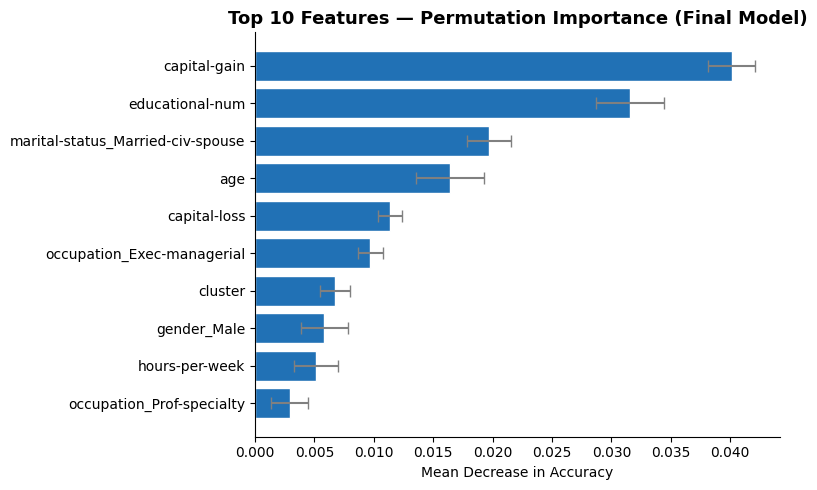

In [40]:
# Visualise top 10 permutation importances
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['feature'][::-1], top10['importance_mean'][::-1],
        xerr=top10['importance_std'][::-1],
        color='#2171b5', ecolor='gray', capsize=4, edgecolor='white')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_title('Top 10 Features — Permutation Importance (Final Model)',
             fontsize=13, fontweight='bold')
sns.despine(); plt.tight_layout(); plt.show()


---
## Comparison — Part 1 vs Part 2 Top 10 Features

### Part 2 Final Model — Top 10 Features (by permutation importance)

| Rank | Feature | Importance |
|---|---|---|
| 1 | `capital-gain` | 0.0401 |
| 2 | `educational-num` | 0.0316 |
| 3 | `marital-status_Married-civ-spouse` | 0.0197 |
| 4 | `age` | 0.0164 |
| 5 | `capital-loss` | 0.0114 |
| 6 | `occupation_Exec-managerial` | 0.0097 |
| 7 | **`cluster`** *(engineered)* | 0.0067 |
| 8 | `gender_Male` | 0.0058 |
| 9 | `hours-per-week` | 0.0051 |
| 10 | `occupation_Prof-specialty` | 0.0029 |

### Are there new features in the top 10?
**Yes — `cluster` appears at rank 7.** This is the KMeans cluster label engineered in Part 2,
meaning group membership carries enough signal to outrank `gender_Male`, `hours-per-week`, and
`occupation_Prof-specialty`. The PCA components (`PC1`, `PC2`, `PC3`) did **not** make the top 10
or even pass the `SelectFromModel` threshold — only `cluster` survived feature selection among
the engineered features.

### How does this compare to Part 1?
The original demographic predictors remain dominant — `capital-gain`, `educational-num`, `age`,
marital status, and occupation dummies still drive most of the prediction in both models.
Part 2 added one new useful feature (`cluster`) but did not change the core story.

### Does feature engineering + selection improve performance?

| Model | # Features | Test Accuracy | Train Time |
|---|---|---|---|
| Part 1 Baseline | 80 | 83.83% | 17.30s |
| Engineered Features | 84 | 83.69% | 11.09s |
| **Final Selected** | **13** | **82.99%** | **7.39s** |

Test accuracy dropped slightly (~0.8 percentage points) but the final model uses **only 13
features instead of 80** — an 84% reduction in feature count — and trains in less than half
the time of the baseline. This is a strong tradeoff: a much leaner, faster, more interpretable
model with minimal accuracy loss.

> **Conclusion:** Feature engineering surfaced one valuable new signal (`cluster`), and
> embedded feature selection produced a model that is dramatically simpler and faster while
> retaining nearly all of the baseline's predictive power. The PCA components added no value
> in this case — the original features already captured the linear signal that PCA would extract.
